In [1]:
import sys

sys.path.append("qualitative_analysis_project")
from qualitative_analysis.metrics import krippendorff, gwet

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pickle
from pathlib import Path
from matplotlib.lines import Line2D
from tqdm.notebook import tqdm

# Results for all generations

In [2]:
my_dico = {}
# To read
with open("dictionnary_MLANG-tests.pkl", "rb") as f:
    my_dico = pickle.load(f)

## Generations

In [4]:
all_models = [(Path("VertexAI/MLANG_2.5-flash-lite_tests/"), "_2.5-flash-lite"), (Path("VertexAI/MLANG_2.5-flash_tests/"), "_2.5-flash"), (Path("VertexAI/MLANG_2.5-pro_tests/"), "_2.5-pro")]
# folder, suffix = Path("VertexAI/MLANG_2.5-flash-lite_tests/"), "_2.5-flash-lite"
# folder, suffix = Path("VertexAI/MLANG_2.5-flash_tests/"), "_2.5-flash"
# folder, suffix = Path("VertexAI/MLANG_2.5-pro_tests/"), "_2.5-pro"

for folder, suffix in all_models:
    for file in tqdm(folder.iterdir()):
        var = file.name[:-4] + suffix

        df = pd.read_csv(file)
        rater_cols = [c for c in df.columns if c.startswith("Rater")]
        df["iteration"] = 1
        df["run"] = 1
        df["prompt_name"] = "streamlit_analysis"
        df["split"] = "train"
        my_dico[var] = {"df": df}

        level = "ordinal"
        domain = [1, 2, 3]

        n = len(df)
        btsp = 200 if n > 3000 else 600 if n > 1000 else 1000 if n > 100 else 2000

        print("")
        print(f"*** {var} ***")
        print(f"   Level: {level}")
        print(f"   Samples: {len(df)}")

        kripp_results = krippendorff.compute_krippendorff_non_inferiority(
        detailed_results_df = df,
        annotation_columns = rater_cols,
        model_column = "rating",
        level_of_measurement = level,
        value_domain = domain,
        non_inferiority_margin = -0.05,
        n_bootstrap = btsp,
        confidence_level = 90.0,
        random_seed = 42,
        verbose = True)

        gwet_results = gwet.compute_gwet_panel_difference(
            detailed_results_df=df,
            annotation_columns=rater_cols,
            model_column="rating",
            ac_weights="quadratic",
            verbose=True,
        )

        my_dico[var]["kripp_results"] = kripp_results
        my_dico[var]["gwet_results"]  = gwet_results

0it [00:00, ?it/s]


*** codebook_2.5-flash-lite ***
   Level: ordinal
   Samples: 272

=== Non-inferiority Test: streamlit_analysis_iteration_1 ===
    Using 19 human annotators
    Human group: all 19 annotators
    Model groups: 19 combinations of LLM + 18 humans


Bootstrap:   0%|          | 0/1000 [00:00<?, ?it/s]


  Run 1:
    Human group (19 annotators) α: 0.8034
    Model groups (LLM + 18 humans) α: 0.1221
    Δ = model − human = -0.6813
    90% CI: [-0.7529, -0.6087]
    ❌ Non-inferiority NOT demonstrated (margin = -0.05)

  Summary across 1 runs:
    Human panel α: 0.8034 ± 0.0000
    Model substitution panel α: 0.1221 ± 0.0000
    Δ = model − human = -0.6813 ± 0.0000
    90% CI: [-0.7529, -0.6087]
    Non-inferiority demonstrated in 0/1 runs
    ❌ Non-inferiority NOT demonstrated in any run (margin = -0.05)

=== Gwet Panel Difference: streamlit_analysis_iteration_1 ===
  Run 1:
    Using 19 human annotators
    Model groups: 19 combinations of LLM + 18 humans
    Gwet weights: 'quadratic' (identity->AC1, weighted->AC2)
    Human panel AC: 0.9163
    Model substitution AC: 0.2173
    Δ = model − human = -0.6990

  Summary across 1 runs:
    Human panel AC: 0.9163 ± 0.0000
    Model substitution AC: 0.2173 ± 0.0000
    Δ = model − human = -0.6990 ± 0.0000

*** codebook_examples-with-no-reaso

Bootstrap:   0%|          | 0/1000 [00:00<?, ?it/s]

...


  Run 1:
    Human group (19 annotators) α: 0.8034
    Model groups (LLM + 18 humans) α: 0.3187
    Δ = model − human = -0.4846
    90% CI: [-0.5566, -0.4135]
    ❌ Non-inferiority NOT demonstrated (margin = -0.05)

  Summary across 1 runs:
    Human panel α: 0.8034 ± 0.0000
    Model substitution panel α: 0.3187 ± 0.0000
    Δ = model − human = -0.4846 ± 0.0000
    90% CI: [-0.5566, -0.4135]
    Non-inferiority demonstrated in 0/1 runs
    ❌ Non-inferiority NOT demonstrated in any run (margin = -0.05)

=== Gwet Panel Difference: streamlit_analysis_iteration_1 ===
  Run 1:
    Using 19 human annotators
    Model groups: 19 combinations of LLM + 18 humans
    Gwet weights: 'quadratic' (identity->AC1, weighted->AC2)
    Human panel AC: 0.9163
    Model substitution AC: 0.5456
    Δ = model − human = -0.3707

  Summary across 1 runs:
    Human panel AC: 0.9163 ± 0.0000
    Model substitution AC: 0.5456 ± 0.0000
    Δ = model − human = -0.3707 ± 0.0000

*** thinking_simplest_2.5-pro ***
 

Bootstrap:   0%|          | 0/1000 [00:00<?, ?it/s]


  Run 1:
    Human group (19 annotators) α: 0.8034
    Model groups (LLM + 18 humans) α: 0.2800
    Δ = model − human = -0.5233
    90% CI: [-0.5971, -0.4498]
    ❌ Non-inferiority NOT demonstrated (margin = -0.05)

  Summary across 1 runs:
    Human panel α: 0.8034 ± 0.0000
    Model substitution panel α: 0.2800 ± 0.0000
    Δ = model − human = -0.5233 ± 0.0000
    90% CI: [-0.5971, -0.4498]
    Non-inferiority demonstrated in 0/1 runs
    ❌ Non-inferiority NOT demonstrated in any run (margin = -0.05)

=== Gwet Panel Difference: streamlit_analysis_iteration_1 ===
  Run 1:
    Using 19 human annotators
    Model groups: 19 combinations of LLM + 18 humans
    Gwet weights: 'quadratic' (identity->AC1, weighted->AC2)
    Human panel AC: 0.9163
    Model substitution AC: 0.4992
    Δ = model − human = -0.4171

  Summary across 1 runs:
    Human panel AC: 0.9163 ± 0.0000
    Model substitution AC: 0.4992 ± 0.0000
    Δ = model − human = -0.4171 ± 0.0000

*** thinking_simplified_2.5-pro ***

Bootstrap:   0%|          | 0/1000 [00:00<?, ?it/s]


  Run 1:
    Human group (19 annotators) α: 0.8034
    Model groups (LLM + 18 humans) α: 0.1773
    Δ = model − human = -0.6261
    90% CI: [-0.6989, -0.5566]
    ❌ Non-inferiority NOT demonstrated (margin = -0.05)

  Summary across 1 runs:
    Human panel α: 0.8034 ± 0.0000
    Model substitution panel α: 0.1773 ± 0.0000
    Δ = model − human = -0.6261 ± 0.0000
    90% CI: [-0.6989, -0.5566]
    Non-inferiority demonstrated in 0/1 runs
    ❌ Non-inferiority NOT demonstrated in any run (margin = -0.05)

=== Gwet Panel Difference: streamlit_analysis_iteration_1 ===
  Run 1:
    Using 19 human annotators
    Model groups: 19 combinations of LLM + 18 humans
    Gwet weights: 'quadratic' (identity->AC1, weighted->AC2)
    Human panel AC: 0.9163
    Model substitution AC: 0.2433
    Δ = model − human = -0.6730

  Summary across 1 runs:
    Human panel AC: 0.9163 ± 0.0000
    Model substitution AC: 0.2433 ± 0.0000
    Δ = model − human = -0.6730 ± 0.0000


# Save and download the dictionnary

In [11]:
# To write
with open("dictionnary_MLANG-tests.pkl", "wb") as f:
    pickle.dump(my_dico, f, protocol=pickle.HIGHEST_PROTOCOL)

In [15]:
# To read
with open("dictionnary_MLANG-tests.pkl", "rb") as f:
    my_dico = pickle.load(f)

# Visualizations

In [3]:
rows_kripp = []

for var, info in my_dico.items():
    results = info["kripp_results"]
    res_key = next(iter(results)) # take first result key: "streamlit_analysis_iteration_1"
    agg = results[res_key]["aggregated_metrics"]

    rows_kripp.append({
        "Variable": var,
        "Human alpha": agg["alpha_human_panel_mean"],
        "Model alpha": agg["alpha_llm_substitution_panel_mean"],
        "Difference": agg["difference_mean"],
        "CI lower": agg["ci_lower_mean"],
        "CI upper": agg["ci_upper_mean"],
        "Non-inferior runs": agg["n_non_inferior"],
        "Total runs": agg["n_runs"],
    })

kripp_df = pd.DataFrame(rows_kripp)
kripp_df

,Variable,Human alpha,Model alpha,Difference,CI lower,CI upper,Non-inferior runs,Total runs
0,codebook_2.5-flash-lite,0.803362,0.122098,-0.681263,-0.752904,-0.608684,0,1
1,codebook_examples-with-no-reasoning_2.5-flash-...,0.803362,0.349378,-0.453984,-0.520640,-0.384673,0,1
2,reasoning_codebook_examples-with-no-reasoning_...,0.803362,0.176354,-0.627007,-0.698734,-0.554506,0,1
3,reasoning_codebook_examples-with-reasoning_2.5...,0.803362,0.480924,-0.322437,-0.388155,-0.253831,0,1
4,simplest_2.5-flash-lite,0.803362,0.023688,-0.779673,-0.844440,-0.711124,0,1
5,simplified_2.5-flash-lite,0.803362,-0.067155,-0.870516,-0.932083,-0.806169,0,1
6,thinking_codebook_2.5-flash-lite,0.803362,0.088193,-0.715169,-0.781066,-0.643709,0,1
7,thinking_codebook_examples-with-no-reasoning_2...,0.803362,0.209181,-0.594181,-0.662904,-0.519386,0,1
8,thinking_codebook_examples-with-reasoning_2.5-...,0.803362,0.267261,-0.536101,-0.608997,-0.460475,0,1
9,thinking_no-scale_2.5-flash-lite,0.803362,0.022710,-0.780652,-0.846386,-0.711379,0,1


In [5]:
rows_ac = []

for var, info in my_dico.items():
    results = info["gwet_results"]
    res_key = next(iter(results)) # take first result key: "streamlit_analysis_iteration_1"
    agg = results[res_key]["aggregated_metrics"]

    rows_ac.append({
        "Variable": var,
        "Human AC": agg["ac_human_panel_mean"],
        "Model AC": agg["ac_llm_substitution_panel_mean"],
        "Delta AC": agg["difference_mean"],
    })

gwet_df = pd.DataFrame(rows_ac)
gwet_df

,Variable,Human AC,Model AC,Delta AC
0,codebook_2.5-flash-lite,0.91627,0.217303,-0.698967
1,codebook_examples-with-no-reasoning_2.5-flash-...,0.91627,0.672940,-0.243330
2,reasoning_codebook_examples-with-no-reasoning_...,0.91627,0.306165,-0.610105
3,reasoning_codebook_examples-with-reasoning_2.5...,0.91627,0.768210,-0.148060
4,simplest_2.5-flash-lite,0.91627,0.057626,-0.858644
5,simplified_2.5-flash-lite,0.91627,-0.162739,-1.079009
6,thinking_codebook_2.5-flash-lite,0.91627,0.141599,-0.774671
7,thinking_codebook_examples-with-no-reasoning_2...,0.91627,0.408158,-0.508112
8,thinking_codebook_examples-with-reasoning_2.5-...,0.91627,0.507343,-0.408927
9,thinking_no-scale_2.5-flash-lite,0.91627,0.055846,-0.860424


In [6]:
model_pattern = r"(2\.5-flash-lite|2\.5-flash|2\.5-pro)"

mapping = {
    "codebook": "cbk",
    "reasoning": "rsng",
    "examples": "ex",
    "thinking": "tkg",
    "with-": ""
}

diff_df = (
    pd.DataFrame(rows_kripp)
    .sort_values("Difference")
    .assign(
        Model=lambda df: df["Variable"].str.extract(model_pattern),
        Variable_clean=lambda df: (
            df["Variable"]
            .str.replace(model_pattern, "", regex=True)
            .replace(mapping, regex=True)
            .str.strip("_- ")
        )
    )
)
diff_df["Variable_clean"]=diff_df["Variable_clean"].str.replace(r"_\d+$", "", regex=True)
# Add delta AC
diff_df = diff_df.merge(
    gwet_df[["Variable", "Delta AC"]],
    on="Variable",
    how="left"
)
diff_df

,Variable,Human alpha,Model alpha,Difference,CI lower,CI upper,Non-inferior runs,Total runs,Model,Variable_clean,Delta AC
0,simplified_2.5-flash-lite,0.803362,-0.067155,-0.870516,-0.932083,-0.806169,0,1,2.5-flash-lite,simplified,-1.079009
1,thinking_simplest_2.5-flash-lite,0.803362,-0.049723,-0.853085,-0.912408,-0.787448,0,1,2.5-flash-lite,tkg_simplest,-1.030773
2,thinking_simplified_2.5-flash-lite,0.803362,-0.010311,-0.813673,-0.876135,-0.745628,0,1,2.5-flash-lite,tkg_simplified,-0.952686
3,thinking_no-scale_2.5-flash-lite,0.803362,0.022710,-0.780652,-0.846386,-0.711379,0,1,2.5-flash-lite,tkg_no-scale,-0.860424
4,simplest_2.5-flash-lite,0.803362,0.023688,-0.779673,-0.844440,-0.711124,0,1,2.5-flash-lite,simplest,-0.858644
5,thinking_codebook_2.5-flash-lite,0.803362,0.088193,-0.715169,-0.781066,-0.643709,0,1,2.5-flash-lite,tkg_cbk,-0.774671
6,codebook_2.5-flash-lite,0.803362,0.122098,-0.681263,-0.752904,-0.608684,0,1,2.5-flash-lite,cbk,-0.698967
7,thinking_no-scale_2.5-flash,0.803362,0.126875,-0.676487,-0.746072,-0.603020,0,1,2.5-flash,tkg_no-scale,-0.712808
8,no-scale_2.5-flash-lite,0.803362,0.141060,-0.662301,-0.734309,-0.589860,0,1,2.5-flash-lite,no-scale,-0.444657
9,thinking_simplified_2.5-flash,0.803362,0.141266,-0.662096,-0.732435,-0.588128,0,1,2.5-flash,tkg_simplified,-0.712241


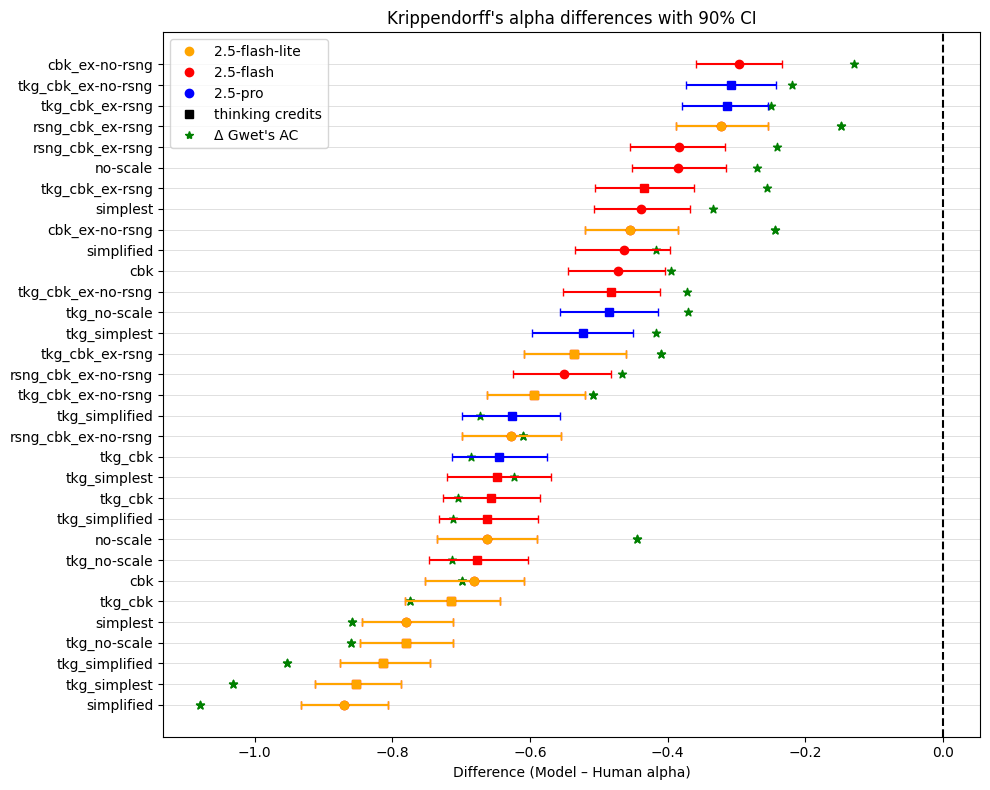

In [8]:
y = np.arange(len(diff_df))

fig, ax = plt.subplots(figsize=(10, 8))

mask1 = diff_df["Variable"].str.contains("2.5-flash")
mask2 = diff_df["Variable"].str.contains("2.5-flash-lite")
mask3 = diff_df["Variable"].str.contains("2.5-pro")

groups = [
    (mask1, "2.5-flash", "red"),
    (mask2, "2.5-flash-lite", "orange"),
    (mask3, "2.5-pro", "blue"),
]

for mask, label, color in groups:
    subset = diff_df.loc[mask]
    y_subset = y[mask]

    # Conditional markers for "thinking" variables
    markers = subset["Variable"].str.contains("thinking", case=False, na=False)
    
    for xi, yi, diff, ci_low, ci_up, is_thinking in zip(
        subset["Difference"],
        y_subset,
        subset["Difference"],
        subset["CI lower"],
        subset["CI upper"],
        markers
    ):
        ax.errorbar(
            xi,
            yi,
            xerr=[[diff - ci_low], [ci_up - diff]],
            fmt='s' if is_thinking else 'o',
            color=color,
            capsize=3,
            label=label
        )
    x_ac = subset["Delta AC"].astype(float).to_numpy()
    y_ac = y_subset
    ax.scatter(
        x_ac,
        y_ac,
        marker="*",
        color="green",
    )

for yi in y:
    ax.axhline(
        yi,
        color="lightgrey",
        linewidth=0.5,
        zorder=0,
    )

ax.axvline(0, color="black", linestyle="--")
ax.set_yticks(y)
ax.set_yticklabels(diff_df["Variable_clean"])
ax.set_xlabel("Difference (Model – Human alpha)")
ax.set_title("Krippendorff's alpha differences with 90% CI")
legend_elements = [
    Line2D([0], [0], marker='o', color='orange', linestyle='None', label='2.5-flash-lite'),
    Line2D([0], [0], marker='o', color='red', linestyle='None', label='2.5-flash'),
    Line2D([0], [0], marker='o', color='blue', linestyle='None', label='2.5-pro'),
    Line2D([0], [0], marker='s', color='black', linestyle='None', label='thinking credits'),
    Line2D([0], [0], marker='*', color='green', linestyle='None', label='Δ Gwet\'s AC'),
]
ax.legend(handles=legend_elements)

plt.tight_layout()
#plt.savefig("kripp_diff_forestplot.png", dpi=300, bbox_inches="tight")
plt.show()

In [11]:
order = [# THINKING EXAMPLES REASONING
         'thinking_codebook_examples-with-reasoning_2.5-flash-lite',
         'thinking_codebook_examples-with-reasoning_2.5-flash',
         'thinking_codebook_examples-with-reasoning_2.5-pro',

        # REASONING EXAMPLES REASONING
         'reasoning_codebook_examples-with-reasoning_2.5-flash-lite',
         'reasoning_codebook_examples-with-reasoning_2.5-flash',
         'reasoning_codebook_examples-with-reasoning_2.5-pro',
         
         # THINKING EXAMPLES no-REASONING
         'thinking_codebook_examples-with-no-reasoning_2.5-flash-lite',
         'thinking_codebook_examples-with-no-reasoning_2.5-flash',
         'thinking_codebook_examples-with-no-reasoning_2.5-pro',

         # REASONING EXAMPLES no-REASONING
         'reasoning_codebook_examples-with-no-reasoning_2.5-flash-lite',
         'reasoning_codebook_examples-with-no-reasoning_2.5-flash',
         'reasoning_codebook_examples-with-no-reasoning_2.5-pro',

         # EXAMPLES no-REASONING
         'codebook_examples-with-no-reasoning_2.5-flash-lite',
         'codebook_examples-with-no-reasoning_2.5-flash',
         'codebook_examples-with-no-reasoning_2.5-pro',
          
          # THINKING CODEBOOK
         'thinking_codebook_2.5-flash-lite',
         'thinking_codebook_2.5-flash',
         'thinking_codebook_2.5-pro',

         # CODEBOOK
         'codebook_2.5-flash-lite',
         'codebook_2.5-flash',
         'codebook_2.5-pro',

         # THINKING SIMPLIFIED
         'thinking_simplified_2.5-flash-lite',
         'thinking_simplified_2.5-flash',
         'thinking_simplified_2.5-pro',

         # SIMPLIFIED
         'simplified_2.5-flash-lite',
         'simplified_2.5-flash',
         'simplified_2.5-pro',
         
         # THINKING SIMPLEST
         'thinking_simplest_2.5-flash-lite',
         'thinking_simplest_2.5-flash',
         'thinking_simplest_2.5-pro',

         # SIMPLEST
         'simplest_2.5-flash-lite',
         'simplest_2.5-flash',
         'simplest_2.5-pro',

         # THINKING no-SCALE
         'thinking_no-scale_2.5-flash-lite',
         'thinking_no-scale_2.5-flash',
         'thinking_no-scale_2.5-pro',

         # no-SCALE
         'no-scale_2.5-flash-lite',
         'no-scale_2.5-flash', 
         'no-scale_2.5-pro',
        ]

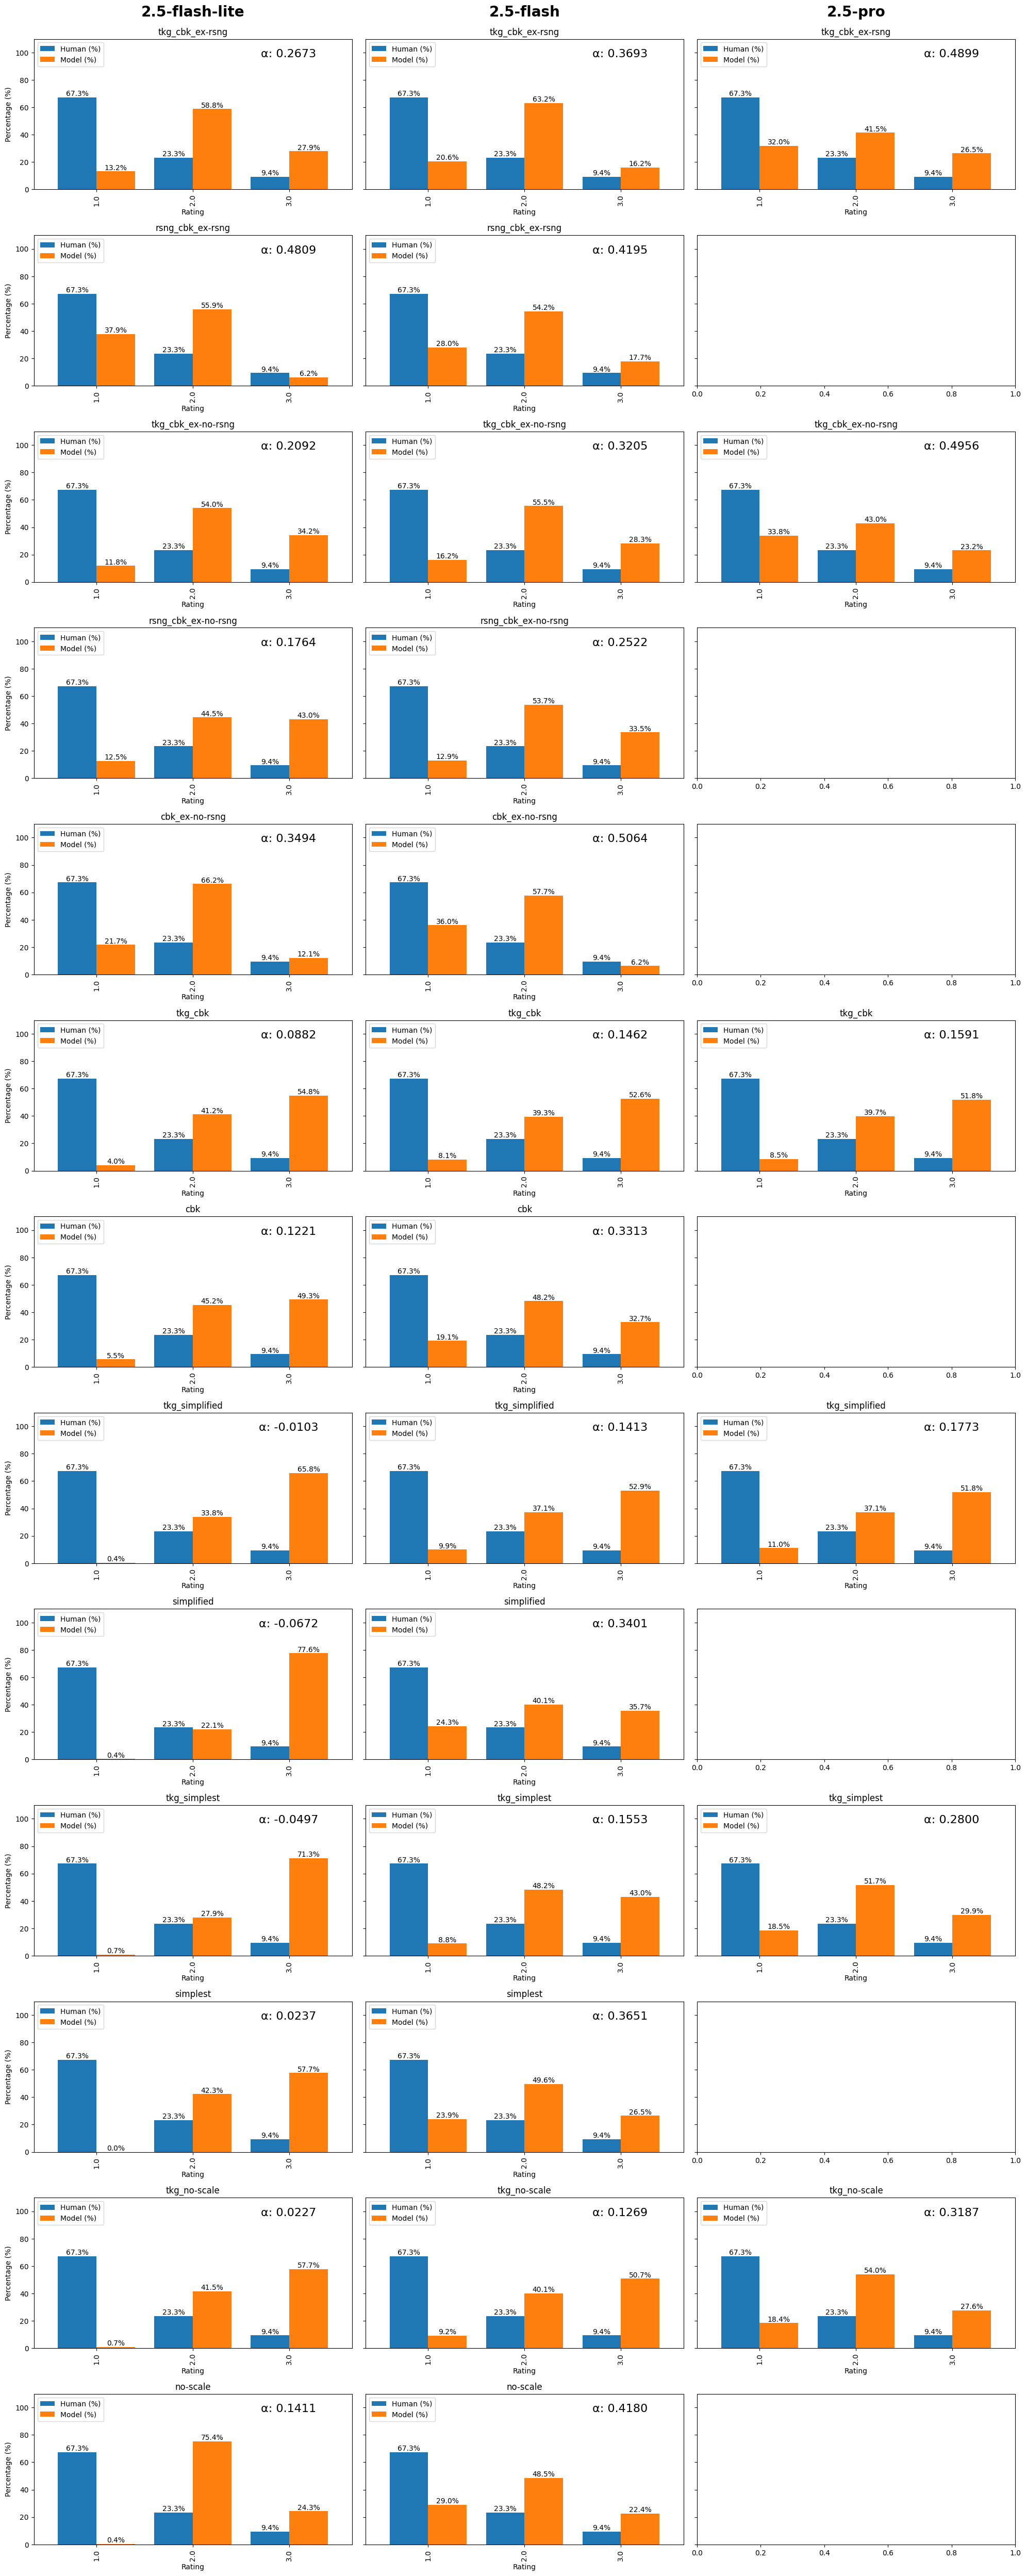

In [16]:
fig, axes = plt.subplots(ncols=3, nrows=13, figsize=(20, 50), sharey=True)#, sharex=True)
axes_flat = axes.flatten()

for (var, ax) in zip(order, axes_flat):
    try:
        df = my_dico[var]["df"]
        rater_cols = [c for c in df.columns if c.startswith("Rater")]

        humans = df[rater_cols].stack().dropna()
        model = df["rating"]

        counts_h = humans.value_counts(normalize=True).sort_index() * 100
        counts_m = model.value_counts(normalize=True).sort_index() * 100

        idx = sorted(set(counts_h.index) | set(counts_m.index))
        plot_df = pd.DataFrame({
            "Human (%)": counts_h,
            "Model (%)": counts_m
        })

        plot_df.plot(kind="bar", ax=ax, width=0.8)
        ax.set_title(diff_df.loc[diff_df["Variable"] == var, "Variable_clean"].iloc[0])
        ax.set_xlabel("Rating")
        ax.set_ylabel("Percentage (%)")
        ax.set_ylim([0, 110])

        # Display percent values
        for container in ax.containers:
            ax.bar_label(container, fmt="%.1f%%")

        value = kripp_df.set_index("Variable").loc[var, "Model alpha"]
        ax.text(
            0.8,
            0.9,
            f"α: {value:.4f}",
            transform=ax.transAxes,
            ha="center",
            va="center",
            fontsize=16
        )
    except KeyError:
        continue

col_titles = ["2.5-flash-lite", "2.5-flash", "2.5-pro"]
for ax, title in zip(axes[0], col_titles):
    ax.annotate(
        title,
        xy=(0.5, 1.15),
        xycoords="axes fraction",
        ha="center",
        fontsize=20,
        weight="bold"
    )

plt.tight_layout()
# plt.savefig("kripp_diff_barplots.png", dpi=300, bbox_inches="tight")
plt.show()

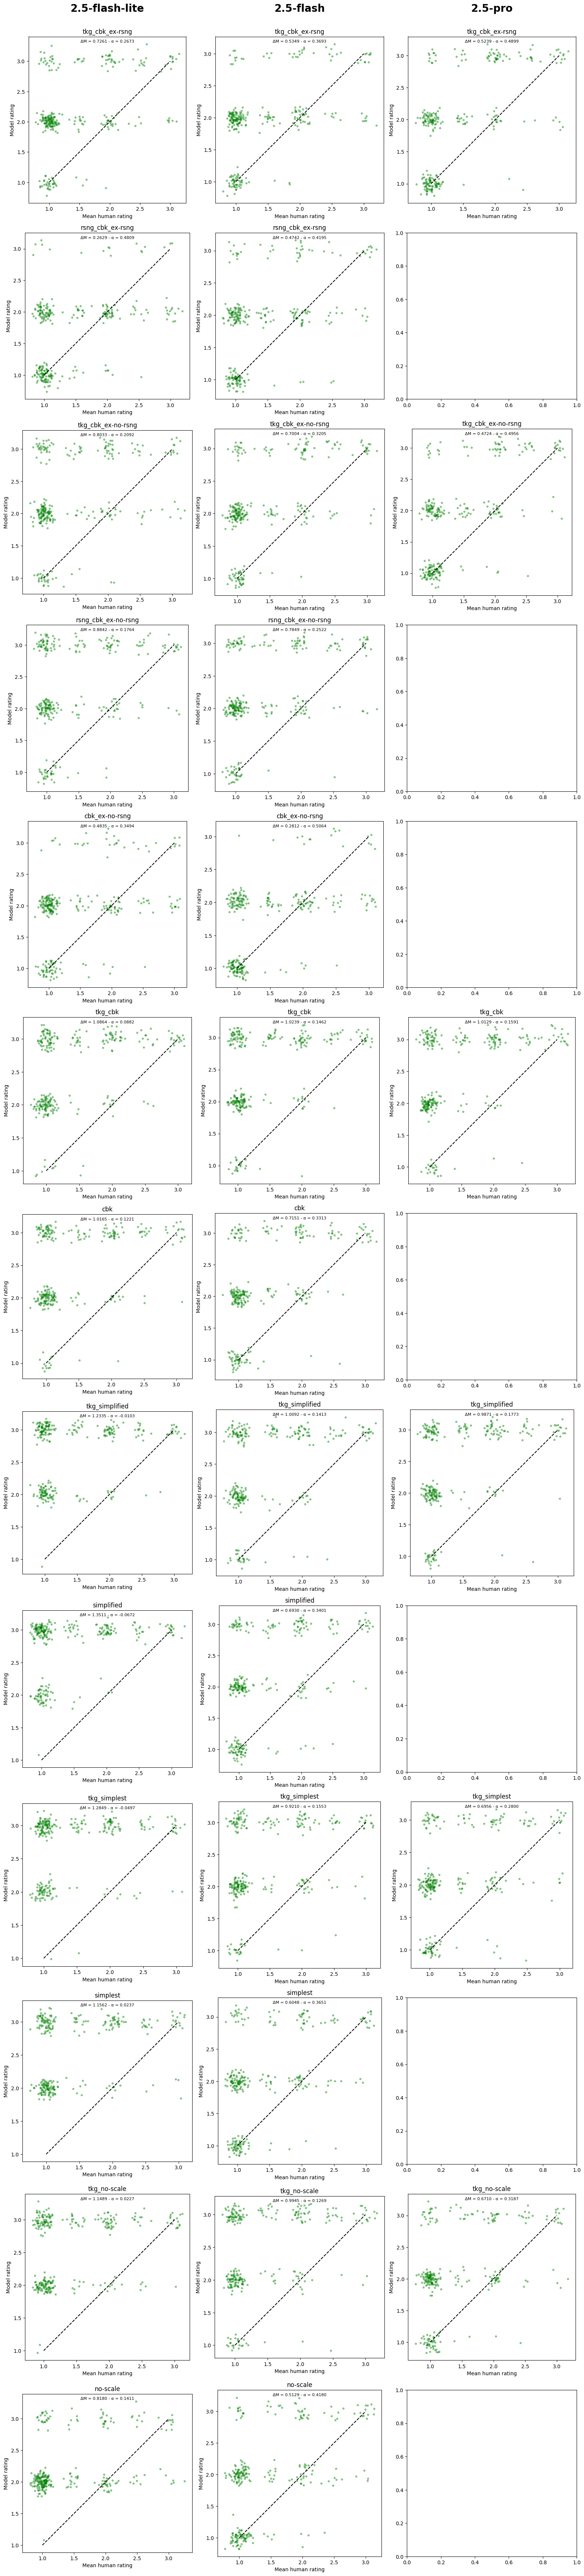

In [17]:
fig, axes = plt.subplots(ncols=3, nrows=13, figsize=(16, 70))
axes_flat = axes.flatten()

for var, ax in zip(order, axes_flat):
    try :
        df = my_dico[var]["df"]
        rater_cols = [c for c in df.columns if c.startswith("Rater")]

        # Human mean per item
        human_mean = df[rater_cols].mean(axis=1, skipna=True)
        model = df["rating"]
        diff_mean = (model - human_mean).mean()
        colors = "green" if diff_mean > 0 else "red"
            
        # Jitter
        jitter_x = np.random.normal(0, 0.08, size=len(human_mean))
        jitter_y = np.random.normal(0, 0.08, size=len(model))

        # Scatter
        ax.scatter(
            human_mean + jitter_x,
            model + jitter_y,
            c=colors,
            alpha=0.4,
            s=10
        )

        # Diagonale y = x
        min_val = min(human_mean.min(), model.min())
        max_val = max(human_mean.max(), model.max())
        ax.plot([min_val, max_val], [min_val, max_val], linestyle="--", color='black')

        # Title
        ax.set_title(diff_df.loc[diff_df["Variable"] == var, "Variable_clean"].iloc[0])
        # Subtitle with ΔM and α
        kripp_val = kripp_df.set_index("Variable").loc[var, "Model alpha"]
        ax.text(0.5, 0.97, f"ΔM = {diff_mean:.4f} - α = {kripp_val:.4f}", ha="center", va="center", transform=ax.transAxes, fontsize=8)

        ax.set_xlabel("Mean human rating")
        ax.set_ylabel("Model rating")
        ax.set_aspect("equal", "box")

    except KeyError:
        continue

col_titles = ["2.5-flash-lite", "2.5-flash", "2.5-pro"]
for ax, title in zip(axes[0], col_titles):
    ax.annotate(
        title,
        xy=(0.5, 1.15),
        xycoords="axes fraction",
        ha="center",
        fontsize=20,
        weight="bold"
    )
    
plt.tight_layout()
plt.show()